# Manual Verification Sample

In [1]:
from pathlib import Path
import sys

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
BACKEND_ROOT = PROJECT_ROOT / 'backend'
if str(BACKEND_ROOT) not in sys.path:
    sys.path.append(str(BACKEND_ROOT))

PROJECT_ROOT

WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon')

In [2]:
import pandas as pd
from PIL import Image
from IPython.display import display

from app.ml.celeba_hair_rich import (
    load_extracted_asset_metadata,
    review_row_from_asset_metadata,
    select_manual_verification_sample,
    write_review_csv,
)

ASSET_ROOT = BACKEND_ROOT / 'data' / 'processed' / 'celeba_hair_rich_assets'
METADATA_ROOT = ASSET_ROOT / 'metadata'
REVIEW_ROOT = ASSET_ROOT / 'review'

PER_GROUP = 20
EXPORT_FULL_TEMPLATE = True

ASSET_ROOT

WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon/backend/data/processed/celeba_hair_rich_assets')

In [3]:
metadata_rows = load_extracted_asset_metadata(METADATA_ROOT)
print('Extracted assets available:', len(metadata_rows))
metadata_rows[0] if metadata_rows else None

Extracted assets available: 250


{'asset_id': 'celeba_hair_000001',
 'source_dataset': 'CelebA',
 'original_celeba_file': '000002.jpg',
 'raw_image_path': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\raw\\celeba\\img_align_celeba\\img_align_celeba\\000002.jpg',
 'raw_mask_path': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\datasets\\celeba_hair_rich\\segmentation_masks\\000002_hair_mask.png',
 'image_path': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\processed\\celeba_hair_rich_assets\\images\\celeba_hair_000001.png',
 'mask_path': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\processed\\celeba_hair_rich_assets\\masks\\celeba_hair_000001_mask.png',
 'partition': 'train',
 'gender_label': 'female',
 'quality_score': 1.0,
 'confidence_bucket': 'high',
 'quality_flags': ['usable_candidate'],
 'hair_mask_stats': {'positive_pixels': 10858,
  'coverage_ratio': 0.279817,
  'b

In [4]:
sample_rows = select_manual_verification_sample(metadata_rows, per_group=PER_GROUP)
review_rows = [review_row_from_asset_metadata(row) for row in sample_rows]
review_frame = pd.DataFrame(review_rows)

print('Manual sample size:', len(review_rows))
review_frame.groupby(['gender_label', 'confidence_bucket']).size().reset_index(name='count')

Manual sample size: 80


,gender_label,confidence_bucket,count
0,female,high,20
1,female,medium,20
2,male,high,20
3,male,medium,20


In [5]:
REVIEW_ROOT.mkdir(parents=True, exist_ok=True)

sample_csv_path = REVIEW_ROOT / 'manual_verification_sample.csv'
write_review_csv(review_rows, sample_csv_path)

full_template_path = None
if EXPORT_FULL_TEMPLATE:
    full_template_rows = [review_row_from_asset_metadata(row) for row in metadata_rows]
    full_template_path = REVIEW_ROOT / 'full_asset_label_template.csv'
    write_review_csv(full_template_rows, full_template_path)

print('Sample CSV:', sample_csv_path)
print('Full template CSV:', full_template_path)

Sample CSV: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\data\processed\celeba_hair_rich_assets\review\manual_verification_sample.csv
Full template CSV: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\data\processed\celeba_hair_rich_assets\review\full_asset_label_template.csv


In [6]:
review_frame.head(20)

,asset_id,image_path,mask_path,partition,gender_label,confidence_bucket,quality_score,color_hint,texture_hint,bangs_hint,...,review_keep,review_gender,review_length,review_curl,review_bang,review_volume,review_side_hair,review_color,review_style_family,review_notes
0,celeba_hair_000001,D:\Projects\Personal Projects\Hairstyle Recomm...,D:\Projects\Personal Projects\Hairstyle Recomm...,train,female,high,1.0,Brown_Hair,None,False,...,,,,,,,,,,
1,celeba_hair_000002,D:\Projects\Personal Projects\Hairstyle Recomm...,D:\Projects\Personal Projects\Hairstyle Recomm...,train,female,high,1.0,Brown_Hair,Wavy_Hair,False,...,,,,,,,,,,
2,celeba_hair_000005,D:\Projects\Personal Projects\Hairstyle Recomm...,D:\Projects\Personal Projects\Hairstyle Recomm...,train,female,high,1.0,Black_Hair,None,False,...,,,,,,,,,,
3,celeba_hair_000008,D:\Projects\Personal Projects\Hairstyle Recomm...,D:\Projects\Personal Projects\Hairstyle Recomm...,train,female,high,1.0,Black_Hair,None,False,...,,,,,,,,,,
4,celeba_hair_000011,D:\Projects\Personal Projects\Hairstyle Recomm...,D:\Projects\Personal Projects\Hairstyle Recomm...,train,female,high,1.0,Blond_Hair,Wavy_Hair,False,...,,,,,,,,,,
5,celeba_hair_000012,D:\Projects\Personal Projects\Hairstyle Recomm...,D:\Projects\Personal Projects\Hairstyle Recomm...,train,female,high,1.0,Blond_Hair,Wavy_Hair,False,...,,,,,,,,,,
6,celeba_hair_000014,D:\Projects\Personal Projects\Hairstyle Recomm...,D:\Projects\Personal Projects\Hairstyle Recomm...,train,female,high,1.0,Blond_Hair,Wavy_Hair,False,...,,,,,,,,,,
7,celeba_hair_000016,D:\Projects\Personal Projects\Hairstyle Recomm...,D:\Projects\Personal Projects\Hairstyle Recomm...,train,female,high,1.0,Blond_Hair,None,False,...,,,,,,,,,,
8,celeba_hair_000018,D:\Projects\Personal Projects\Hairstyle Recomm...,D:\Projects\Personal Projects\Hairstyle Recomm...,train,female,high,1.0,None,Straight_Hair,False,...,,,,,,,,,,
9,celeba_hair_000020,D:\Projects\Personal Projects\Hairstyle Recomm...,D:\Projects\Personal Projects\Hairstyle Recomm...,train,female,high,1.0,Blond_Hair,Wavy_Hair,True,...,,,,,,,,,,


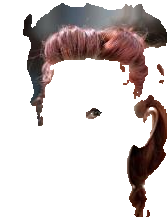

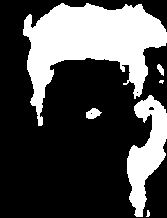

,asset_id,image_path,mask_path,partition,gender_label,confidence_bucket,quality_score,color_hint,texture_hint,bangs_hint,...,review_keep,review_gender,review_length,review_curl,review_bang,review_volume,review_side_hair,review_color,review_style_family,review_notes
0,celeba_hair_000001,D:\Projects\Personal Projects\Hairstyle Recomm...,D:\Projects\Personal Projects\Hairstyle Recomm...,train,female,high,1.0,Brown_Hair,None,False,...,,,,,,,,,,


In [7]:
def preview_asset(asset_id: str):
    row = review_frame.loc[review_frame['asset_id'] == asset_id].iloc[0]
    with Image.open(row['image_path']).convert('RGBA') as image:
        display(image)
    with Image.open(row['mask_path']).convert('L') as mask:
        display(mask)
    display(row.to_frame().T)

if not review_frame.empty:
    preview_asset(review_frame.iloc[0]['asset_id'])